JURNAL MODUL 2

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Import Library

Kode di atas digunakan untuk mengimpor library yang dibutuhkan pada proses pengolahan citra digital.

- `numpy` digunakan untuk operasi matriks dan array pada citra digital.
- `matplotlib.pyplot` digunakan untuk menampilkan gambar, grafik, dan histogram.
- `cv2` (OpenCV) digunakan untuk proses pengolahan citra seperti konversi grayscale, transformasi citra, filtering, dan operasi pengolahan lainnya.

Ketiga library tersebut menjadi dasar utama dalam proses pengolahan citra pada modul ini.

(720, 720, 3)


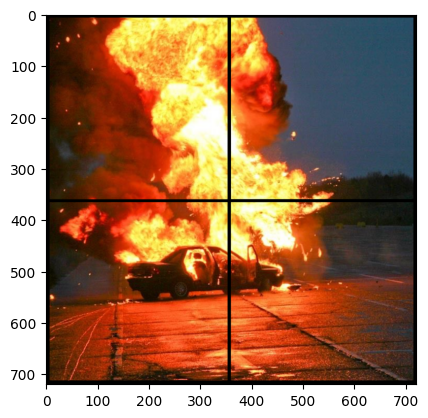

In [14]:
gambarA = plt.imread('Assets/Meledak.png')
plt.imshow(gambarA)
print(gambarA.shape)

(720, 720, 3)


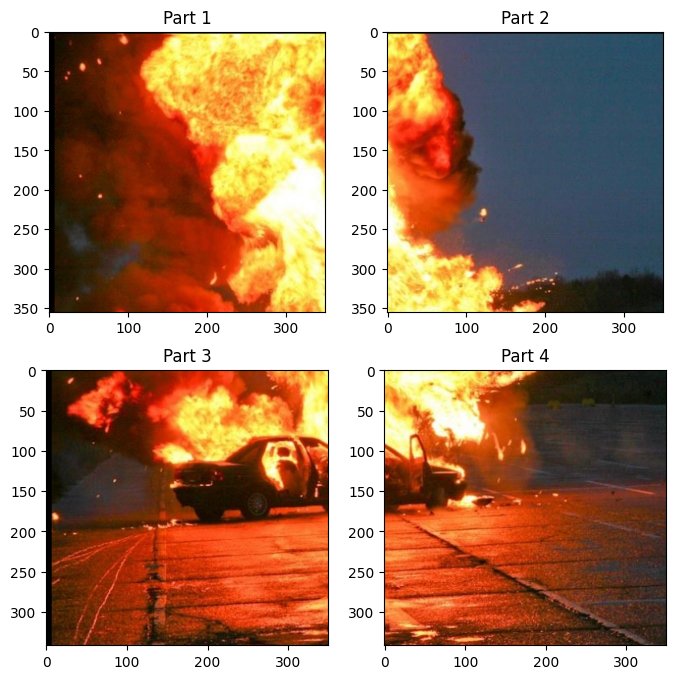

In [15]:
tinggi, lebar, channel = gambarA.shape

tengah_tinggi = tinggi // 2
tengah_lebar = lebar // 2

bagian1 = gambarA[5:360, 0:350]
bagian2 = gambarA[5:360, 360:710]
bagian3 = gambarA[368:710, 0:350]
bagian4 = gambarA[368:710, 360:710]

fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(bagian1)
ax[0,0].set_title('Part 1')
ax[0,1].imshow(bagian2)
ax[0,1].set_title('Part 2')
ax[1,0].imshow(bagian3)
ax[1,0].set_title('Part 3')
ax[1,1].imshow(bagian4)
ax[1,1].set_title('Part 4')

print(gambarA.shape)
plt.show()


In [16]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

Text(0.5, 1.0, 'Hasil Gabungan')

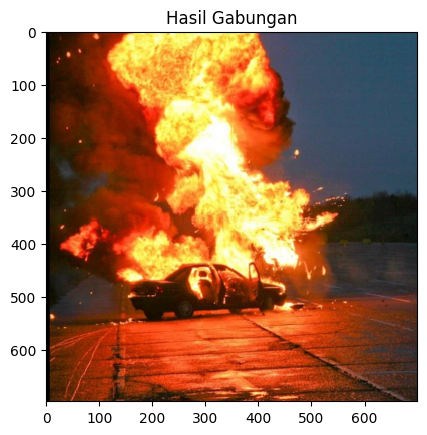

In [17]:
gabung1 = merge_image(bagian1, bagian2, orientation='H')
gabung2 = merge_image(bagian3, bagian4, orientation='H')
gabung3 = merge_image(gabung1, gabung2, orientation='V')
plt.imshow(gabung3)
plt.title('Hasil Gabungan')

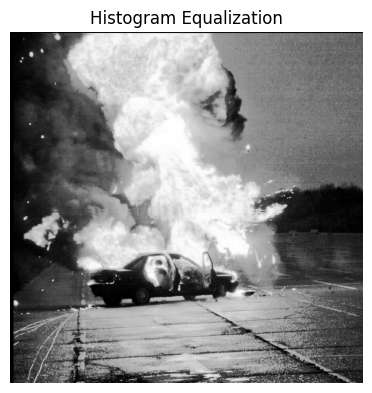

In [28]:
grayscale = cv2.cvtColor(gabung3, cv2.COLOR_RGB2GRAY)
grayscale = (grayscale * 255).astype(np.uint8)

equal = cv2.equalizeHist(grayscale)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(equal, cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

plt.show()

In [30]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1
 
    return histogram 

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show()

def ekualisasi(citra): 
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1
    
    # Hitung CDF
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]
    
    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    
    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra) 
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]
    
    return hasil
print(grayscale.dtype)
print(grayscale.min(), grayscale.max())


uint8
0 255


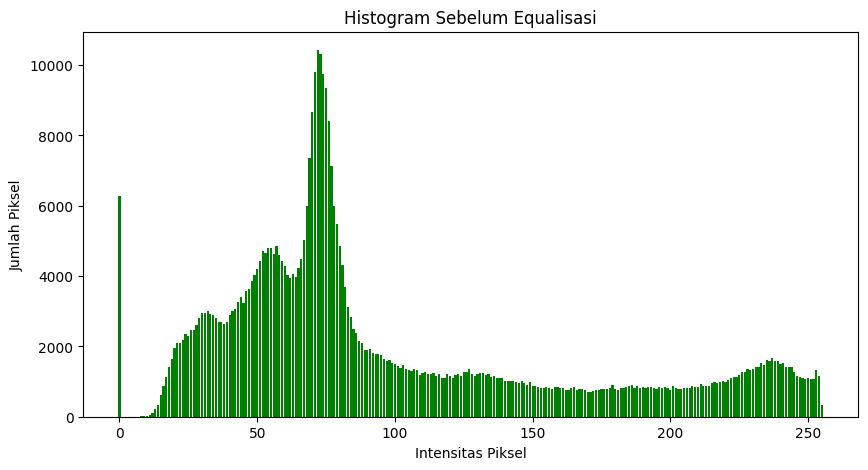

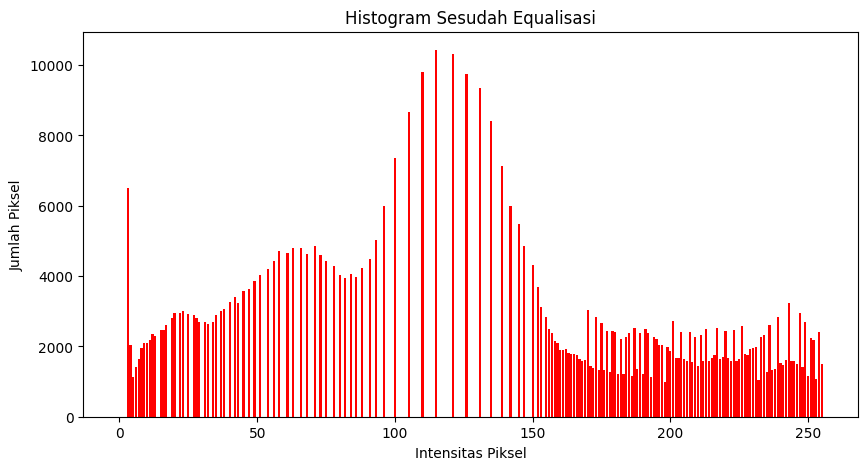

In [31]:
hist_sebelum = buat_hist(grayscale)
plot_histogram(hist_sebelum, "Histogram Sebelum Equalisasi", 'Green')
equal_gray = ekualisasi(grayscale)
hist_sesudah = buat_hist(equal_gray)
plot_histogram(hist_sesudah, "Histogram Sesudah Equalisasi", 'Red')

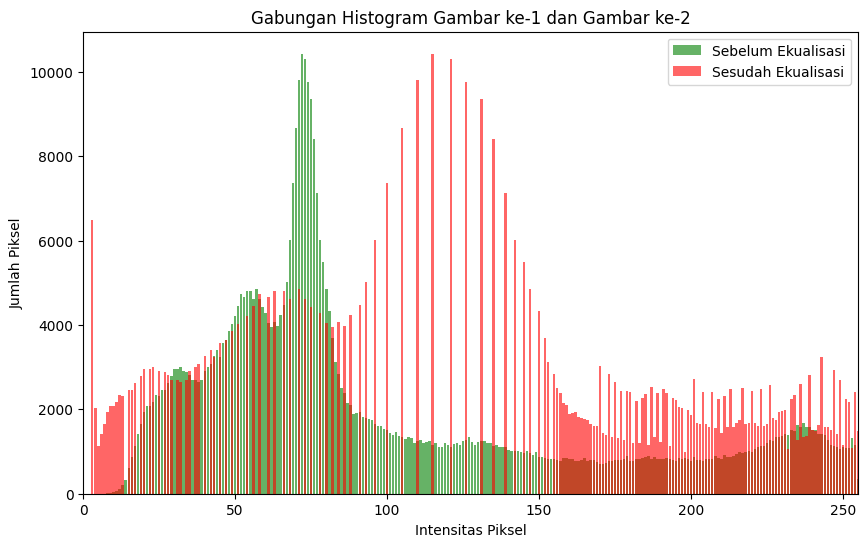

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(range(256),
        hist_sebelum, color='green',
        alpha=0.6, label='Sebelum Ekualisasi',
        width=0.8)

plt.bar(range(256),
        hist_sesudah, color='red',
        alpha=0.6, label='Sesudah Ekualisasi',
        width=0.8)

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')

plt.xlabel('Intensitas Piksel')

plt.ylabel('Jumlah Piksel')

plt.legend(loc='upper right')

plt.xlim([0, 255])

plt.show()

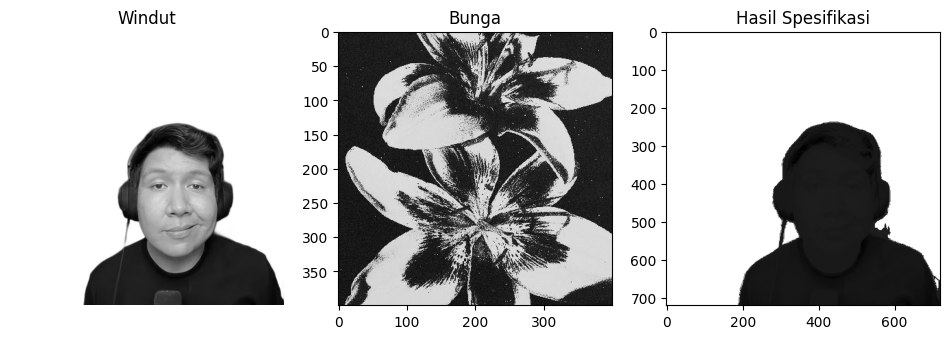

In [ ]:

windut = cv2.imread('Assets/Windut.png', 0)
bunga = cv2.imread('Assets/Bunga.png', 0)

def histogram_specification(source_image, target_image):

    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            pixel = source_image[i, j]
            hist_source[pixel] += 1

    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            pixel = target_image[i, j]
            hist_target[pixel] += 1

    cdf_source = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_source[0] = hist_source[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_source[i] = cdf_source[i-1] + hist_source[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_source = cdf_source / cdf_source[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):

        selisih = np.abs(cdf_source[i] - cdf_target)
        map_hist[i] = np.argmin(selisih)

    height, width = source_image.shape

    result = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):

            result[i, j] = map_hist[source_image[i, j]]

    return result

hasil = histogram_specification(windut, bunga)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(windut, cmap='gray')
plt.title("Windut")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(bunga, cmap='gray')
plt.title("Bunga")
plt.axis('on')

plt.subplot(1,3,3)
plt.imshow(hasil, cmap='gray')
plt.title("Hasil Spesifikasi")
plt.axis('on')

plt.show()

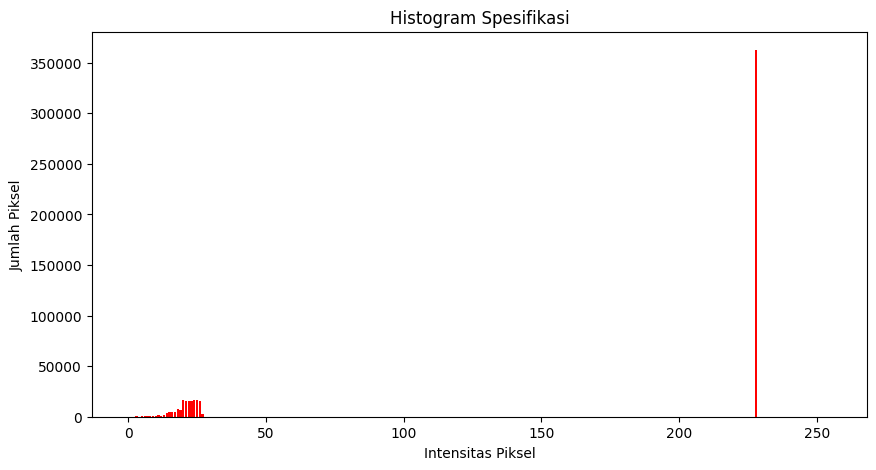

In [ ]:
hist_spesifikasi = buat_hist(hasil)
plot_histogram(hist_spesifikasi, "Histogram Spesifikasi", 'Red')

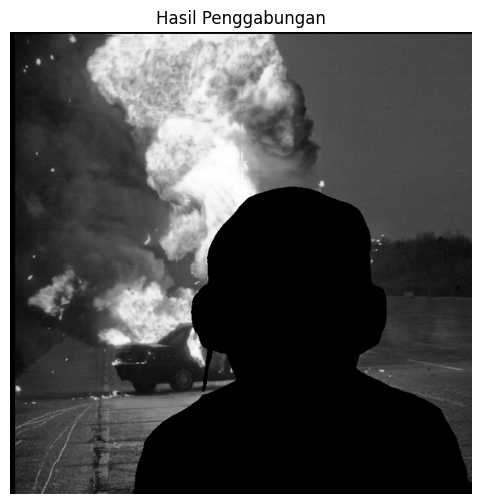

In [ ]:
tinggi_target = hasil.shape[0]
lebar_target = hasil.shape[1]

bg_manual = np.zeros((tinggi_target, lebar_target), dtype=grayscale .dtype)

tinggi_asli = grayscale.shape[0]
lebar_asli = grayscale.shape[1]

for i in range(tinggi_target):
    for j in range(lebar_target):

        y = int(i * tinggi_asli / tinggi_target)
        x = int(j * lebar_asli / lebar_target)

        if y >= tinggi_asli:
            y = tinggi_asli - 1

        if x >= lebar_asli:
            x = lebar_asli - 1

        bg_manual[i, j] = grayscale[y, x]

hasil = cv2.cvtColor(windut, cv2.COLOR_GRAY2BGR)
bg_manual = cv2.cvtColor(bg_manual, cv2.COLOR_GRAY2BGR)

for i in range(hasil.shape[0]):
    for j in range(hasil.shape[1]):

        if windut[i, j] > 230:
            hasil[i, j] = bg_manual[i, j]

        else:
            hasil[i, j] = [0, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
plt.title("Hasil Penggabungan")
plt.axis('off')
plt.show()

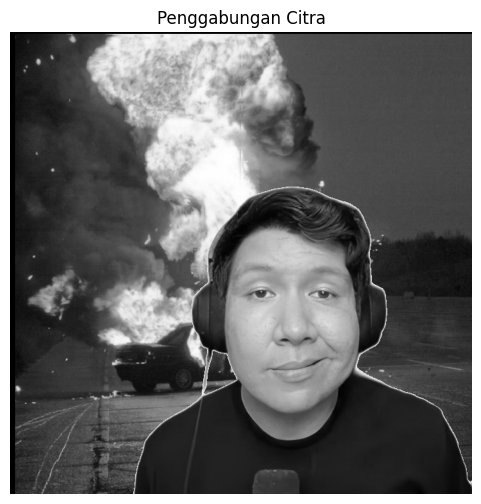

In [ ]:
hasil_merge = hasil.copy()
windut_bgr = cv2.cvtColor(windut, cv2.COLOR_GRAY2BGR)

for i in range(windut.shape[0]):
    for j in range(windut.shape[1]):

        if windut[i, j] < 240:
            hasil_merge[i, j] = windut_bgr[i, j]

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(hasil_merge, cv2.COLOR_BGR2RGB))
plt.title("Penggabungan Citra")
plt.axis('off')
plt.show()

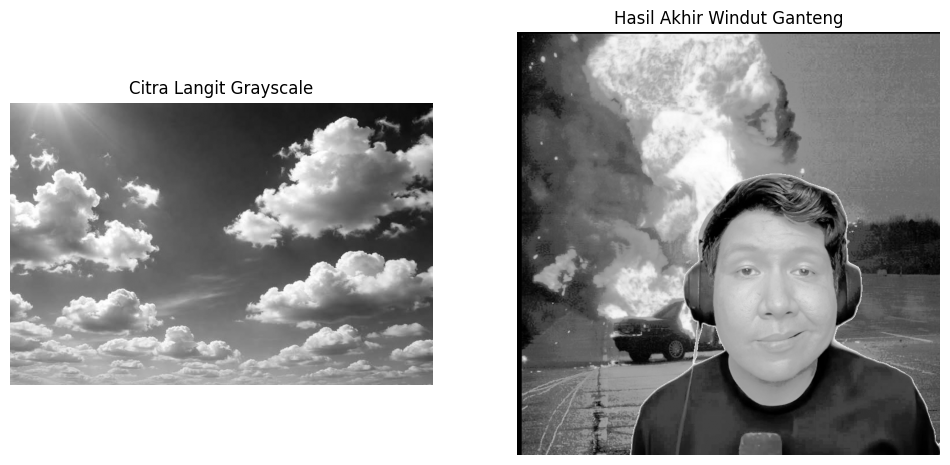

In [ ]:
langit = cv2.imread('Assets/Langit.png')

langit_gray = cv2.cvtColor(langit, cv2.COLOR_BGR2GRAY)

hasil_gray = cv2.cvtColor(hasil_merge, cv2.COLOR_BGR2GRAY)

hasil_ganteng = histogram_specification(hasil_gray, langit_gray)

hasil_ganteng = cv2.convertScaleAbs(hasil_ganteng, alpha=0.9, beta=-10)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(langit_gray, cmap='gray')
plt.title("Citra Langit Grayscale")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_ganteng, cmap='gray')
plt.title("Hasil Akhir Windut Ganteng")
plt.axis('off')

plt.show()

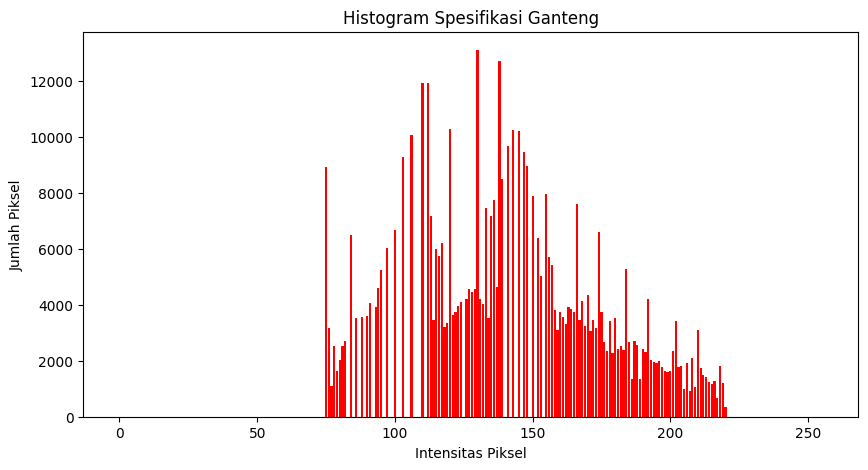

In [ ]:
hist_spesifikasi_ganteng = buat_hist(hasil_ganteng)
plot_histogram(hist_spesifikasi_ganteng, "Histogram Spesifikasi Ganteng", 'red')

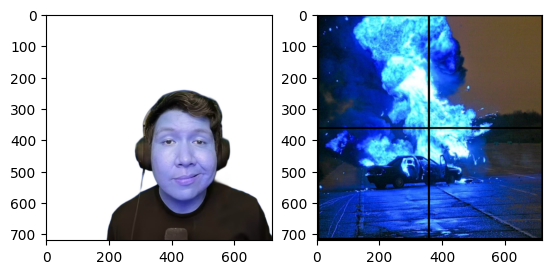

In [ ]:
ledakBiru = cv2.imread("Assets/Windut.png")
background = cv2.imread("Assets/Meledak.png")
plt.subplot(1, 2, 1)
plt.imshow(ledakBiru)
plt.subplot(1, 2, 2)
plt.imshow(background)

(356, 348, 3)
(356, 348, 3)
(350, 348, 3)
(350, 348, 3)


(np.float64(-0.5), np.float64(347.5), np.float64(349.5), np.float64(-0.5))

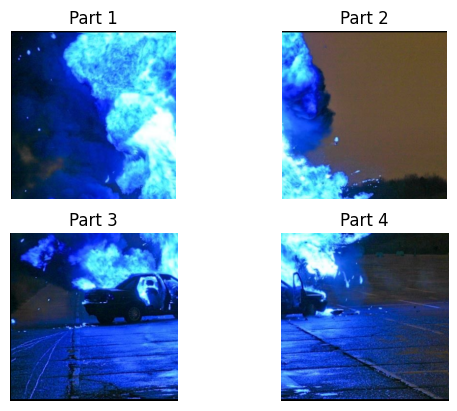

In [ ]:
background1 = background[4:360, 5:353]
background2 = background[4:360, 367:715]
background3 = background[367:717, 5:353]
background4 = background[367:717, 367:715]
plt.subplot(2, 2, 1)
plt.title("Part 1")
plt.imshow(background1)
plt.axis("off")
print(background1.shape)
plt.subplot(2, 2, 2)
plt.title("Part 2")
plt.imshow(background2)
plt.axis("off")
print(background2.shape)
plt.subplot(2, 2, 3)
plt.title("Part 3")
plt.imshow(background3)
plt.axis("off")
print(background3.shape)
plt.subplot(2, 2, 4)
plt.title("Part 4")
plt.imshow(background4)
print(background4.shape)
plt.axis("off")

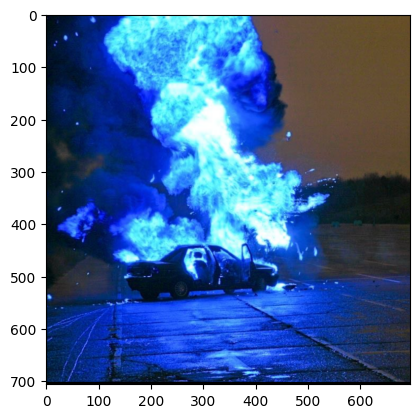

In [ ]:
bg_gabung1 = merge_image(background1, background2, 'H')
bg_gabung2 = merge_image(background3, background4, 'H')
bg_gabung = merge_image(bg_gabung1, bg_gabung2, 'v')

plt.imshow(bg_gabung)

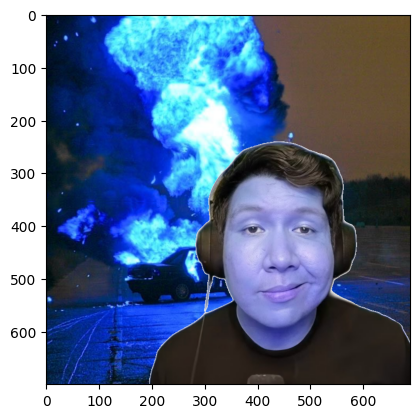

In [ ]:
hasil = np.zeros_like(ledakBiru, dtype=int)

for i in range(bg_gabung.shape[0]):
    for j in range(bg_gabung.shape[1]):
        
        if ledakBiru[i, j, 0] > 235:
            hasil[i, j] = bg_gabung[i, j]
        else:
            hasil[i,j] = ledakBiru[i, j]
            
hasil = hasil[0:700, 0: 690]
plt.imshow(hasil, cmap="gray")
plt.show()

Kesimpulan Praktikum Modul 2

Pada praktikum Modul 2 telah dilakukan berbagai proses pengolahan citra digital, yaitu histogram equalization, histogram specification, masking, dan penggabungan citra. Proses diawali dengan mengubah citra RGB menjadi grayscale serta melakukan split dan merge citra untuk memahami manipulasi piksel pada gambar digital.

Histogram equalization dilakukan untuk meningkatkan kontras citra sehingga detail objek terlihat lebih jelas dan distribusi intensitas piksel menjadi lebih merata. Selanjutnya, histogram specification digunakan untuk menyesuaikan karakteristik pencahayaan dan kontras citra terhadap citra target agar tampilan visual lebih seragam.

Selain itu, dilakukan proses crop dan masking untuk memisahkan objek dengan background sebelum citra digabungkan. Berdasarkan hasil praktikum, dapat disimpulkan bahwa histogram equalization efektif meningkatkan kualitas kontras citra, sedangkan histogram specification efektif menyamakan distribusi intensitas citra sehingga menghasilkan tampilan yang lebih baik dan harmonis.